In [1]:
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ultranest
from ultranest.plot import PredictionBand, cornerplot
import george

In [2]:
urllib.request.urlretrieve(
    "https://berkeley-earth-temperature.s3.us-west-1.amazonaws.com/Global/Land_and_Ocean_summary.txt",
    "Land_and_Ocean_complete_annual.txt"
)
data = np.loadtxt("Land_and_Ocean_complete_annual.txt", comments="%")
columns = [
    "year",
    "annual_anomaly_above", "annual_unc_above",
    "five_year_anomaly_above", "five_year_unc_above",
    "annual_anomaly_below", "annual_unc_below",
    "five_year_anomaly_below", "five_year_unc_below",
]

df = pd.DataFrame(data, columns=columns)

dtype_map = {
    "year": "int",
    "annual_anomaly_above": "float",
    "annual_unc_above": "float",
    "five_year_anomaly_above": "float",
    "five_year_unc_above": "float",
    "annual_anomaly_below": "float",
    "annual_unc_below": "float",
    "five_year_anomaly_below": "float",
    "five_year_unc_below": "float",
}
df = df.astype(dtype_map)

yerr_above = df["annual_unc_above"] / 1.96
yerr_below = df["annual_unc_below"] / 1.96

date = df["year"].values
temp_anomaly = df["annual_anomaly_above"].values
sigma2 = yerr_above ** 2

## Gaussian Processes


In [3]:
# gaussian process model used in every regression (with/whithout trends)
def gp_model(amplitude, length_scale, yerr):
    kernel = amplitude**2 * george.kernels.ExpSquaredKernel(length_scale**2, axes=0)
    gp = george.GP(kernel)
    gp.compute(date.astype(float), yerr)
    return gp


In [4]:
# no trend

def gp_prior(cube):
    params = cube.copy()

    lo_0 = 0.0
    hi_0 = 5.0
    params[0] = lo_0 + cube[0] * (hi_0 - lo_0)

    lo_1 = 0.0
    hi_1 = 100.0
    params[1] = lo_1 + cube[1] * (hi_1 - lo_1)

    return params

def log_gp_likelihood(params):
    amp, length = params

    if amp <= 0 or length <= 0:
        return -1e300

    gp = gp_model(amplitude=amp, length_scale=length, yerr=yerr_above.to_numpy())
    log_likelihood_value = gp.log_likelihood(temp_anomaly, quiet=True)

    if not np.isfinite(log_likelihood_value):
        return -1e300

    return log_likelihood_value


parameters_gp = ["amplitude", "length_scale"]

In [5]:
sampler_gp = ultranest.ReactiveNestedSampler(parameters_gp, log_gp_likelihood, gp_prior)
result_gp = sampler_gp.run(min_ess=1000)
print(result_gp)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=2e+01  21.8103..21.8103]*| it/evals=6570/9016 eff=76.2535% N=400         0  
[ultranest] Likelihood function evaluations: 9020
[ultranest]   logZ = 9.975 +- 0.1573
[ultranest] Effective samples strategy satisfied (ESS = 1626.6, need >1000)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.16, need <0.5)
[ultranest]   logZ error budget: single: 0.16 bs:0.16 tail:0.01 total:0.16 required:<0.50
[ultranest] done iterating.
{'niter': 6975, 'logz': np.float64(9.985400712259699), 'logzerr': np.float64(0.3250731157948344), 'logz_bs': np.float64(9.974600763075216), 'logz_single': np.float64(9.985400712259699), 'logzerr_tail': np.float64(0.009929060499928255), 'logzerr_bs': np.float64(0.32492144338309004), 'ess': np.float64(1626.5824223936445), 'H': np.float64(10.804695512569984), 'Herr': np.float64(0.1521868634828204), 'posterior': {'mean': [0.33525694130501976

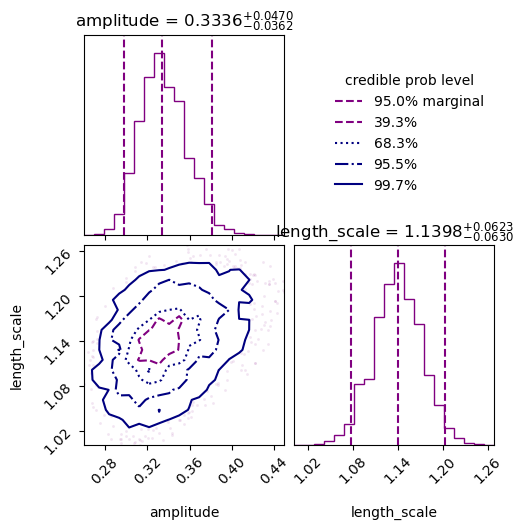

In [6]:
cornerplot(
    result_gp,
    title_fmt=".4f",
    #plot_density=True,
    plot_datapoints=True,
    plot_contours=True,
    use_math_text=True,
    quantiles=[0.025, 0.5, 0.975],
    smooth=False
)
plt.show()
#print(np.exp(result_gp["samples"][0][0]), np.exp(result_gp["samples"][0][1]))

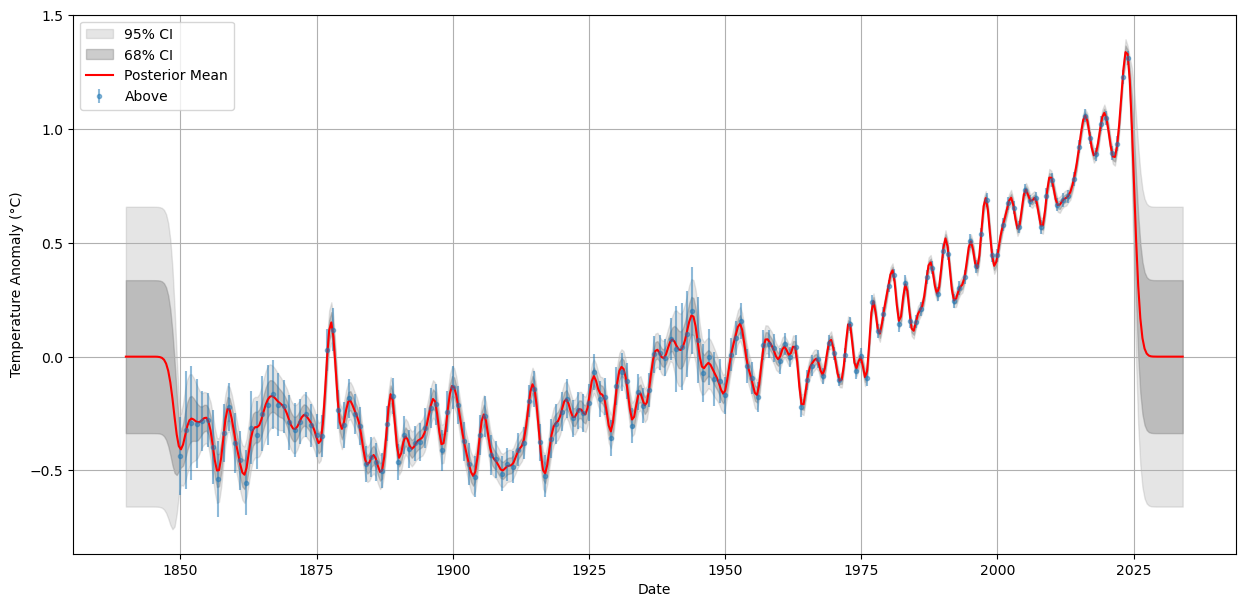

In [9]:
plt.figure(figsize=(15, 7))
plt.errorbar(df["year"], df["annual_anomaly_above"], yerr=df["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)

year_range = np.linspace(df["year"].min()-10, df["year"].max()+10, 500)
yerr = yerr_above.to_numpy()

# Collect predictions and variances from all posterior samples
means = []
variances = []
for params in result_gp["samples"]:
    amp, length = params
    gp = gp_model(amplitude=amp, length_scale=length, yerr=yerr)
    mu, var = gp.predict(temp_anomaly, year_range.astype(float), return_var=True)
    means.append(mu)
    variances.append(var)

means = np.array(means)
variances = np.array(variances)

# Combine across posterior samples using law of total variance
# E[Y] = mean of posterior means, Var[Y] = E[Var[Y|θ]] + Var[E[Y|θ]]
mean_pred = np.mean(means, axis=0)
var_pred = np.mean(variances, axis=0) + np.var(means, axis=0)
std_pred = np.sqrt(var_pred)

# Plot confidence intervals
plt.fill_between(year_range, mean_pred - 1.96*std_pred, mean_pred + 1.96*std_pred, color="gray", alpha=0.2, label="95% CI")
plt.fill_between(year_range, mean_pred - 1.0*std_pred, mean_pred + 1.0*std_pred, color="gray", alpha=0.4, label="68% CI")
plt.plot(year_range, mean_pred, color="red", linewidth=1.5, label="Posterior Mean")

plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.show()

In [10]:
def linear_trend(x, intercept, slope):
    return intercept + slope * x

def gp_linear_prior(cube):
    params = np.empty_like(cube)
    
    lo_0 = -2000.0
    hi_0 = 2000.0
    params[0] = lo_0 + cube[0] * (hi_0 - lo_0)

    lo_1 = -5.
    hi_1 = 5.
    params[1] = lo_1 + cube[1] * (hi_1 - lo_1)

    lo_2 = 1e-3
    hi_2 = 10.0
    params[2] = lo_2 + cube[2] * (hi_2 - lo_2)

    lo_3 = 1e-5
    hi_3 = 200.0
    params[3] = lo_3 + cube[3] * (hi_3 - lo_3)

    return params

def log_gp_likelihood(params):
    intercept, slope, amp, length = params

    if amp <= 0 or length <= 0:
        return -1e300

    trend = linear_trend(date, intercept, slope)
    gp = gp_model(amplitude=amp, length_scale=length, yerr=yerr_above.to_numpy())
    log_likelihood_value = gp.log_likelihood(temp_anomaly - trend, quiet=True)

    if not np.isfinite(log_likelihood_value):
        return -1e300

    return log_likelihood_value

parameters_linear_gp = ["trend_intercept", "trend_slope", "amplitude", "length_scale"]

In [11]:
sampler_linear_gp = ultranest.ReactiveNestedSampler(parameters_linear_gp, log_gp_likelihood, gp_linear_prior)
result_linear_gp = sampler_linear_gp.run()
print(result_linear_gp)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=9e+01  86.7533..86.7533]*| it/evals=15400/54611 eff=28.4075% N=400         0    0  0 0  
[ultranest] Likelihood function evaluations: 54683
[ultranest]   logZ = 52.81 +- 0.2192
[ultranest] Effective samples strategy satisfied (ESS = 2148.8, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.04 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.22, need <0.5)
[ultranest]   logZ error budget: single: 0.28 bs:0.22 tail:0.01 total:0.22 required:<0.50
[ultranest] done iterating.
{'niter': 15832, 'logz': np.float64(52.83569777294554), 'logzerr': np.float64(0.4703079158355212), 'logz_bs': np.float64(52.81109594713623), 'logz_single': np.float64(52.83569777294554), 'logzerr_tail': np.float64(0.009944862513250996), 'logzerr_bs': np.float64(0.47020275988890603), 'ess': np.float64(2148.8445443633022), 'H': np.float64(32.01581975453066), 'Herr': np.float64(0.22102006867143145), 'posterior': {'mean': [-13.87

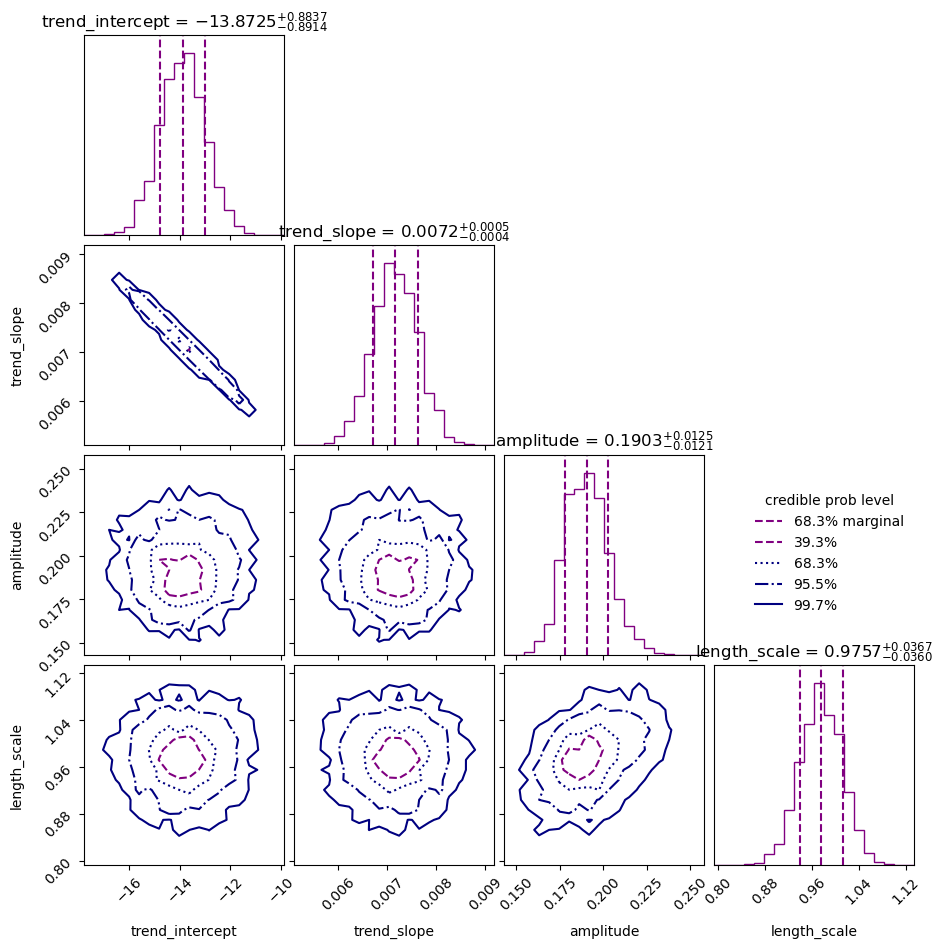

In [12]:
cornerplot(
    result_linear_gp,
    title_fmt=".4f",
    #quantiles=[0.025, 0.5, 0.975]
)
plt.show()

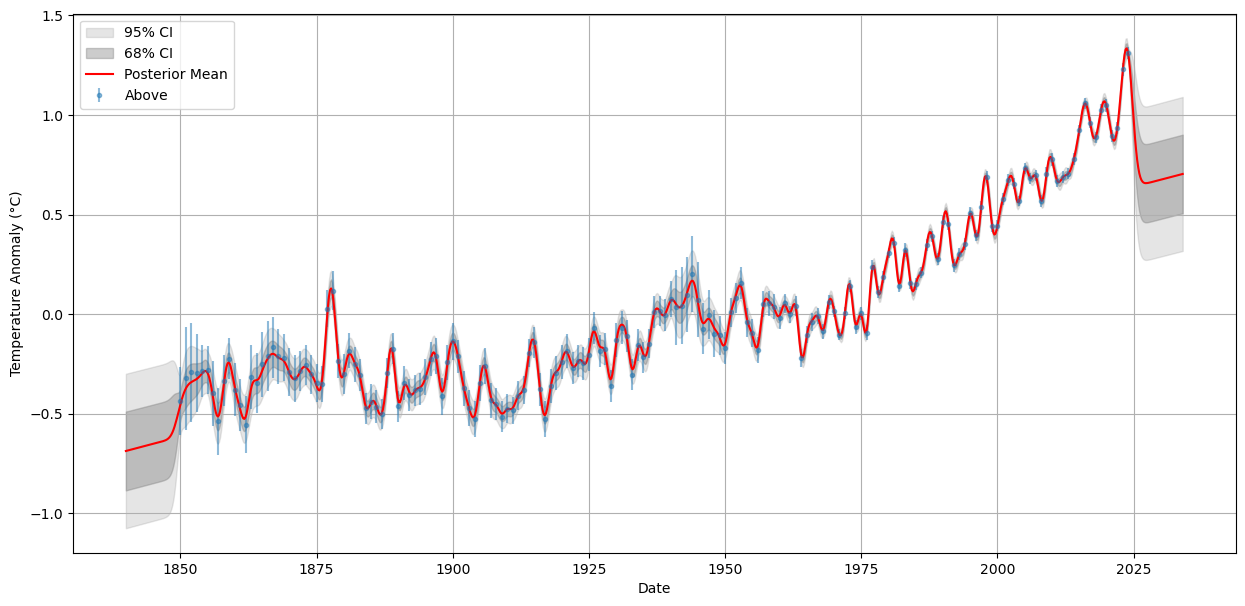

In [13]:
plt.figure(figsize=(15, 7))
plt.errorbar(df["year"], df["annual_anomaly_above"], yerr=df["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)

year_range = np.linspace(df["year"].min() - 10, df["year"].max() + 10, 1000)
yerr = yerr_above.to_numpy()

# Collect predictions and variances from all posterior samples
means = []
variances = []
for params in result_linear_gp["samples"]:
    intercept, slope, amp, length = params
    gp = gp_model(amplitude=amp, length_scale=length, yerr=yerr)
    trend_obs = linear_trend(date, intercept, slope)
    trend_pred = linear_trend(year_range, intercept, slope)
    mu, var = gp.predict(temp_anomaly - trend_obs, year_range.astype(float), return_var=True)
    means.append(mu + trend_pred)
    variances.append(var)

means = np.array(means)
variances = np.array(variances)

# Combine across posterior samples using law of total variance
mean_pred = np.mean(means, axis=0)
var_pred = np.mean(variances, axis=0) + np.var(means, axis=0)
std_pred = np.sqrt(var_pred)

# Plot confidence intervals
plt.fill_between(year_range, mean_pred - 1.96*std_pred, mean_pred + 1.96*std_pred, color="gray", alpha=0.2, label="95% CI")
plt.fill_between(year_range, mean_pred - 1.0*std_pred, mean_pred + 1.0*std_pred, color="gray", alpha=0.4, label="68% CI")
plt.plot(year_range, mean_pred, color="red", linewidth=1.5, label="Posterior Mean")

plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.show()

In [12]:
def exponential_trend(x, q, a, m):
    t = (np.asarray(x) - 1950.0) / 50.0
    return q + a * np.exp(m * t)

def gp_prior(cube):
    params = cube.copy()

    lo_0 = -2.0
    hi_0 = 2.0
    params[0] = lo_0 + cube[0] * (hi_0 - lo_0)

    lo_1 = -2.0
    hi_1 = 2.0
    params[1] = lo_1 + cube[1] * (hi_1 - lo_1)

    lo_2 = -4.0
    hi_2 = 4.0
    params[2] = lo_2 + cube[2] * (hi_2 - lo_2)

    lo_3 = 1e-3
    hi_3 = 10.0
    params[3] = lo_3 + cube[3] * (hi_3 - lo_3)

    lo_4 = 1e-5
    hi_4 = 200.0
    params[4] = lo_4 + cube[4] * (hi_4 - lo_4)

    return params

def log_gp_likelihood(params):
    q, a, m, amp, length = params

    if amp <= 0 or length <= 0:
        return -1e300

    trend = exponential_trend(date, q, a, m)
    gp = gp_model(amplitude=amp, length_scale=length, yerr=yerr_above.to_numpy())
    log_likelihood_value = gp.log_likelihood(temp_anomaly - trend, quiet=True)

    if not np.isfinite(log_likelihood_value):
        return -1e300

    return log_likelihood_value

parameters_gp = ["trend_q", "trend_a", "trend_m", "amplitude", "length_scale"]

In [13]:
sampler_exp_gp = ultranest.ReactiveNestedSampler(parameters_gp, log_gp_likelihood, gp_prior)
result_exp_gp = sampler_exp_gp.run()
print(result_exp_gp)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=1e+02  5 [140.1776..140.1780]*| it/evals=12800/198378 eff=6.4654% N=400    0  
[ultranest] Likelihood function evaluations: 198434
[ultranest]   logZ = 112.7 +- 0.2166
[ultranest] Effective samples strategy satisfied (ESS = 2409.6, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.09 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.19 to 0.60, need <0.5)
[ultranest]   logZ error budget: single: 0.25 bs:0.22 tail:0.01 total:0.22 required:<0.50
[ultranest] done iterating.
{'niter': 13219, 'logz': np.float64(112.82721122005645), 'logzerr': np.float64(0.23496665882354947), 'logz_bs': np.float64(112.7301270407659), 'logz_single': np.float64(112.82721122005645), 'logzerr_tail': np.float64(0.009945483019706103), 'logzerr_bs': np.float64(0.23475608219214905), 'ess': np.float64(2409.563223465415), 'H': np.float64(25.037373295367686), 'Herr': np.float64(0.20711214863348243), 'post

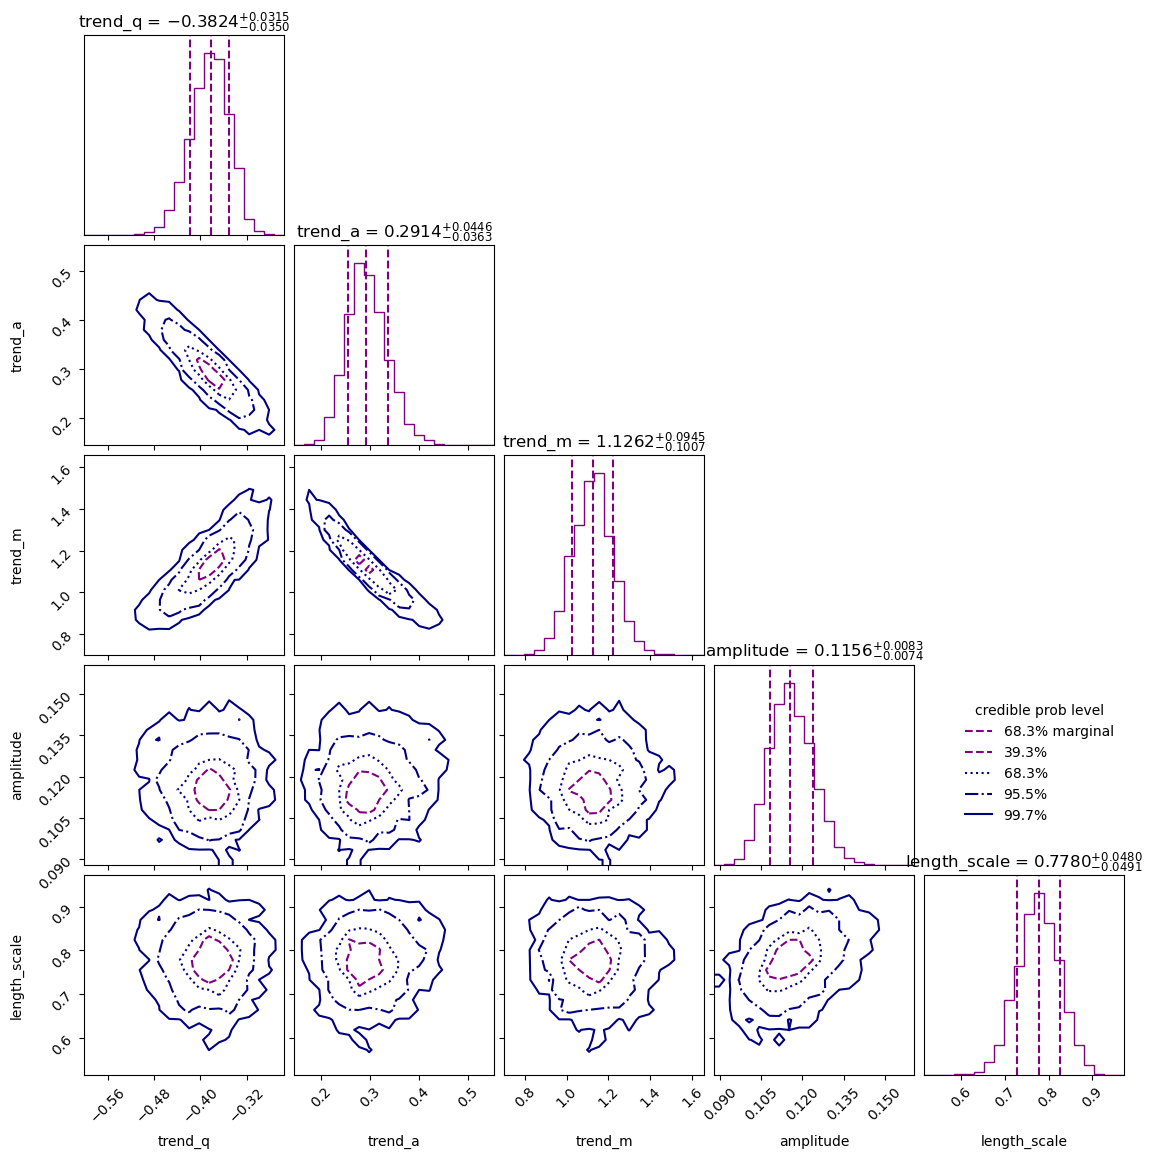

In [14]:
cornerplot(
    result_exp_gp,
    title_fmt=".4f",
    #quantiles=[0.025, 0.5, 0.975]
)
plt.show()

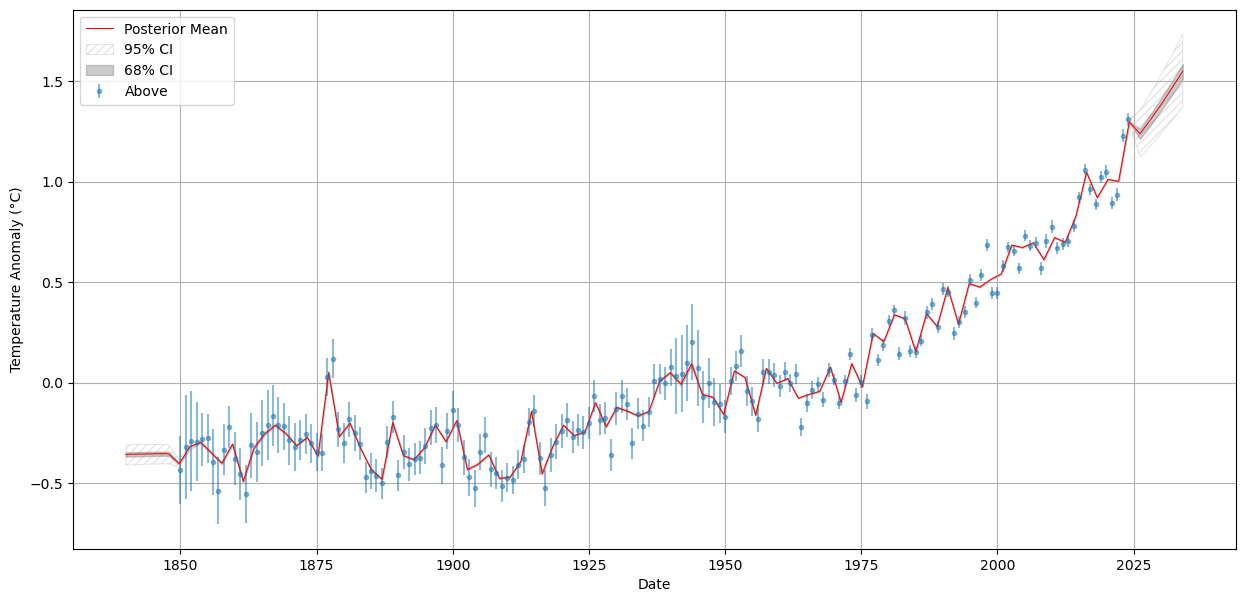

In [ ]:
plt.figure(figsize=(15, 7))
plt.errorbar(df["year"], df["annual_anomaly_above"], yerr=df["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)

year_range = np.linspace(df["year"].min() - 10, df["year"].max() + 10, 500)
yerr = yerr_above.to_numpy()

# Collect predictions and variances from all posterior samples
means = []
variances = []
for params in result_exp_gp["samples"]:
    q, a, m, amp, length = params
    gp = gp_model(amplitude=amp, length_scale=length, yerr=yerr)
    trend_obs = exponential_trend(date, q, a, m)
    trend_pred = exponential_trend(year_range, q, a, m)
    mu, var = gp.predict(temp_anomaly - trend_obs, year_range.astype(float), return_var=True)
    means.append(mu + trend_pred)
    variances.append(var)

means = np.array(means)
variances = np.array(variances)

# Combine across posterior samples using law of total variance
mean_pred = np.mean(means, axis=0)
var_pred = np.mean(variances, axis=0) + np.var(means, axis=0)
std_pred = np.sqrt(var_pred)

# Plot confidence intervals
plt.fill_between(year_range, mean_pred - 1.96*std_pred, mean_pred + 1.96*std_pred, color="gray", alpha=0.2, label="95% CI")
plt.fill_between(year_range, mean_pred - 1.0*std_pred, mean_pred + 1.0*std_pred, color="gray", alpha=0.4, label="68% CI")
plt.plot(year_range, mean_pred, color="red", linewidth=1.5, label="Posterior Mean")

plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.show()

In [16]:
# save results to file
import pickle
from pathlib import Path

In [17]:
out_dir = Path("results")
out_dir.mkdir(exist_ok=True)

to_save = {
    "result_gp": result_gp,
    "result_linear_gp": result_linear_gp,
    "result_exp_gp": result_exp_gp,
}

with open(out_dir / "gp_results.pkl", "wb") as f:
    pickle.dump(to_save, f)

# to load later:
#with open("results/gp_results.pkl", "rb") as f:
#    results = pickle.load(f)
#
#result_gp = results["result_gp"]
#result_linear_gp = results["result_linear_gp"]
#result_exp_gp = results["result_exp_gp"]

$$ y = q + \gamma ~ exp \left( \tau t \right) + a ~ sin \left( \frac{2 \pi t}{p} + \phi \right) $$

In [13]:
def exponential_sine_trend(x, q, gamma, tau, a, p, phi):
    t = (np.asarray(x) - 1950.0) / 50.0
    return q + gamma * np.exp(tau * t) + a * np.sin(2 * np.pi * t / p + phi)

def gp_expsine_prior(cube):
    params = cube.copy()
    #q
    lo_0 = -2.0
    hi_0 = 2.0
    params[0] = lo_0 + cube[0] * (hi_0 - lo_0)
    #gamma
    lo_1 = -2.0
    hi_1 = 2.0
    params[1] = lo_1 + cube[1] * (hi_1 - lo_1)
    #tau
    lo_2 = -4.0
    hi_2 = 4.0
    params[2] = lo_2 + cube[2] * (hi_2 - lo_2)
    #a
    lo_3 = 1e-3
    hi_3 = 5.0
    params[3] = lo_3 + cube[3] * (hi_3 - lo_3)
    #p
    lo_4 = 1e-5
    hi_4 = 20
    params[4] = lo_4 + cube[4] * (hi_4 - lo_4)
    #phi
    lo_5 = 0.0
    hi_5 = 2.0 * np.pi
    params[5] = lo_5 + cube[5] * (hi_5 - lo_5)
    #amp
    lo_6 = 1e-3
    hi_6 = 10.0
    params[6] = lo_6 + cube[6] * (hi_6 - lo_6)
    #length scale
    lo_7 = 1e-5
    hi_7 = 200.0
    params[7] = lo_7 + cube[7] * (hi_7 - lo_7)

    return params

def log_expsine_gp_likelihood(params):
    q, gamma, tau, a, p, phi, amp, length = params

    if amp <= 0 or length <= 0:
        return -1e300

    trend = exponential_sine_trend(date, q, gamma, tau, a, p, phi)
    gp = gp_model(amplitude=amp, length_scale=length, yerr=yerr_above.to_numpy())
    log_likelihood_value = gp.log_likelihood(temp_anomaly - trend, quiet=True)

    if not np.isfinite(log_likelihood_value):
        return -1e300

    return log_likelihood_value

parameters_expsine_gp = ["trend_q", "trend_gamma", "trend_tau", "trend_a", "trend_p", "trend_phi", "amplitude", "length_scale"]

In [14]:
sampler_expsine_gp = ultranest.ReactiveNestedSampler(parameters_expsine_gp, log_expsine_gp_likelihood, gp_expsine_prior)
result_expsine_gp = sampler_expsine_gp.run()
print(result_expsine_gp)

[ultranest] Sampling 400 live points from prior ...


/home/steve/projects/lab-dati-02/.conda/lib/python3.11/site-packages/ultranest/integrator.py:1903: UserWarning: Sampling from region seems inefficient (0/40 accepted in iteration 2500). To improve efficiency, modify the transformation so that the current live points are ellipsoidal, or use a stepsampler, or set frac_remain to a lower number (e.g., 0.5) to terminate earlier.
  u, v, logl, nc, quality = self._refill_samples(Lmin, ndraw, nit)


KeyboardInterrupt: 